In [13]:
import requests
import time

success = 0
error = 0

for i in range(100):
    try:
        response = requests.get("https://latest-960957615762.me-central1.run.app/getbalance")

        if response.status_code == 200:
            print(i + 1, "Success")
            success += 1
        else:
            print(i + 1, "Error, code:", response.status_code)
            error += 1

    except Exception as e:
        print(i + 1, "Exception:", e)
        error += 1

1 Success
2 Success
3 Success
4 Success
5 Success
6 Success
7 Success
8 Success
9 Error, code: 500
10 Success
11 Error, code: 500
12 Success
13 Success
14 Success
15 Error, code: 500
16 Success
17 Success
18 Success
19 Success
20 Success
21 Success
22 Success
23 Success
24 Success
25 Success
26 Success
27 Success
28 Success
29 Success
30 Error, code: 500
31 Success
32 Success
33 Success
34 Success
35 Error, code: 500
36 Error, code: 500
37 Success
38 Success
39 Success
40 Success
41 Success
42 Success
43 Success
44 Error, code: 500
45 Error, code: 500
46 Error, code: 503
47 Success
48 Error, code: 500
49 Success
50 Success
51 Error, code: 500
52 Success
53 Success
54 Error, code: 500
55 Success
56 Success
57 Success
58 Success
59 Success
60 Error, code: 500
61 Success
62 Success
63 Success
64 Success
65 Success
66 Success
67 Success
68 Success
69 Success
70 Error, code: 500
71 Success
72 Success
73 Error, code: 500
74 Success
75 Success
76 Success
77 Success
78 Success
79 Success
80 Su

In [15]:
import requests

response = requests.get("https://latest-960957615762.me-central1.run.app/getlogs")

with open("logs.txt", "w") as f:
    f.write(response.text)

print("File 'logs.txt' created.")

File 'logs.txt' created.


In [17]:
processed_count = 0
warning_count = 0
db_error_count = 0
internal_error_count = 0

with open("logs.txt", "r") as f:
    for line in f:
        if "Processing GET request" in line:
            processed_count += 1
        elif "WARNING" in line:
            warning_count += 1
        elif "Database Connection Pool Empty" in line:
            db_error_count += 1
        elif "Internal Server Error" in line:
            internal_error_count += 1

total_errors = db_error_count + internal_error_count
success_count = processed_count - total_errors
reliability = (success_count / processed_count) * 100

print("Total Requests Processed:", processed_count)
print("Warnings:", warning_count)
print("Database Connection Errors:", db_error_count)
print("Internal Server Errors:", internal_error_count)
print("Total Errors:", total_errors)
print("Successful Requests:", success_count)


Total Requests Processed: 118
Warnings: 28
Database Connection Errors: 27
Internal Server Errors: 25
Total Errors: 52
Successful Requests: 66


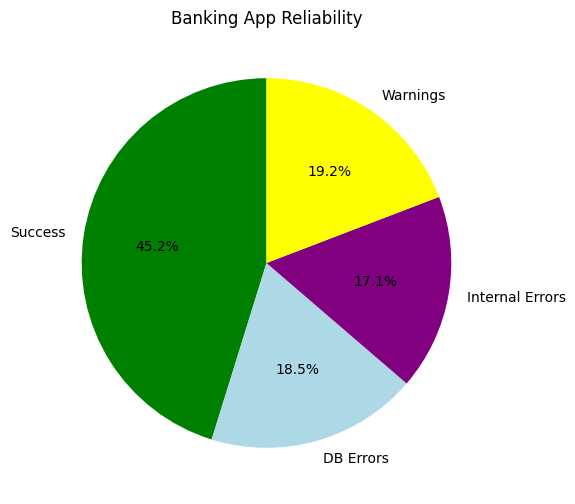

In [18]:
import matplotlib.pyplot as plt

labels = ["Success", "DB Errors", "Internal Errors", "Warnings"]
values = [success_count, db_error_count, internal_error_count, warning_count]
colors = ["green", "lightblue", "purple", "yellow"]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title("Banking App Reliability")
plt.show()
